In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pk
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import root_mean_squared_error
!python -V

Python 3.12.7


#### dev

In [2]:
df = pd.read_parquet('./data/green_tripdata_2024-12.parquet')
df.passenger_count.value_counts()

passenger_count
1.0    43175
2.0     5129
5.0     1221
6.0      918
0.0      747
3.0      507
4.0      303
8.0        6
9.0        4
7.0        3
Name: count, dtype: int64

#### functions

In [3]:
def read_process_data(filename: str) -> pd.DataFrame:
    df = pd.read_parquet(filename)
    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda x: x.total_seconds() / 60)
    df = df[(df.duration <= 60) & (df.duration >= 1)]
    df['pickup_weekday'] =    df.lpep_pickup_datetime.dt.weekday
    df['pickup_hour'] = df.lpep_pickup_datetime.dt.hour
    df['PY_DO'] = df.PULocationID.astype(str) + '_' + df.DOLocationID.astype(str)
    cat = ['pickup_weekday', 'pickup_hour', 'PY_DO']
    num = ['trip_distance']
    target = 'duration'
    df = df[cat + num + [target]]
    df[cat] = df[cat].astype(str)

    return df


#### training

In [4]:
df_train = read_process_data('./data/green_tripdata_2024-12.parquet')
df_val = read_process_data('./data/green_tripdata_2025-01.parquet')

cat = ['pickup_hour', 'pickup_weekday', 'PY_DO']
num = ['trip_distance']
target = 'duration'

dv = DictVectorizer()
train_dicts = df_train[cat + num].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)
y_train = df_train[target].values
val_dicts = df_val[cat + num].to_dict(orient='records')
X_val = dv.transform(val_dicts)
y_val = df_val[target].values

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### plots

RMSE train: 4.844093311166202
RMSE val: 5.711276040807805


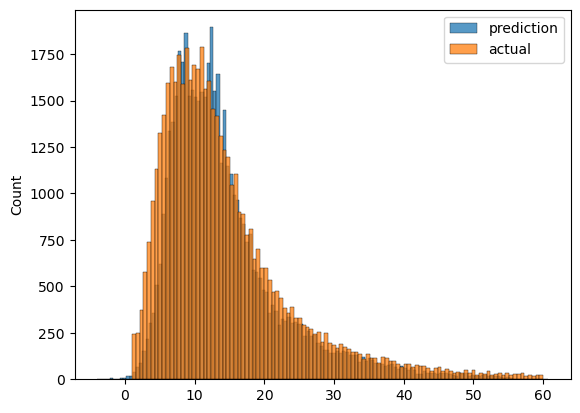

In [5]:
y_pred_train = model.predict(X_train)
print(f'RMSE train: {root_mean_squared_error(y_train, y_pred_train)}')
y_pred_val = model.predict(X_val)
print(f'RMSE val: {root_mean_squared_error(y_val, y_pred_val)}')

sns.histplot(y_pred_train, label='prediction')
sns.histplot(y_train, label='actual')
plt.legend()
plt.show()

#### saving the model

In [9]:
with open('./models/lin_reg.bin', 'wb') as f_out:
    pk.dump((model, dv), f_out)
